In [9]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# output folders
OUT_FIG = Path("/content/figures"); OUT_TAB = Path("/content/tables")
OUT_FIG.mkdir(parents=True, exist_ok=True); OUT_TAB.mkdir(parents=True, exist_ok=True)

# find the 30-min file
cands = ["/content/sample_data/nsw_30mins.csv",
         "/content/nsw_30mins.csv",
         "/content/drive/MyDrive/nsw_30mins.csv"]
raw_fallback = "https://raw.githubusercontent.com/mae-li-unsw/project/main/data/NSW/processed/nsw_30mins.csv"

PATH_30 = next((p for p in cands if os.path.exists(p)), raw_fallback)
print("Reading:", PATH_30)

df = pd.read_csv(PATH_30, low_memory=False)
print("rows x cols:", df.shape)
df.head(3)


Reading: /content/sample_data/nsw_30mins.csv
rows x cols: (195953, 8)


,DATETIME,TEMPERATURE,TOTALDEMAND,FORECASTDEMAND,error,extreme_flag,extreme_type,year
0,2010-01-01,23.1,8038.00,7999.11,38.89,False,Normal,2010
1,2010-01-01 00:30:00,22.9,7809.31,7596.21,213.10,False,Normal,2010
2,2010-01-01 01:00:00,22.6,7483.69,7380.70,102.99,False,Normal,2010


In [10]:
def find_col(frame, names):
    low = {c.lower(): c for c in frame.columns}
    for n in names:
        if n.lower() in low:
            return low[n.lower()]
    return None

# detect likely columns (case-insensitive)
dt = find_col(df, ["DATETIME","SETTLEMENTDATE","timestamp","TIMESTAMP","date","Date"])
y  = find_col(df, ["TOTALDEMAND","totaldemand","actual","demand","load"])
t  = find_col(df, ["TEMPERATURE","temperature","temp","t","air_temp","tmax","t_mean"])

# rename to standard labels
ren = {}
if dt and dt!="DATETIME": ren[dt]="DATETIME"
if y  and y !="TOTALDEMAND": ren[y]="TOTALDEMAND"
if t  and t !="TEMPERATURE": ren[t]="TEMPERATURE"
if ren: df = df.rename(columns=ren)

# parse datetime, strip tz, drop NaT
df["DATETIME"] = pd.to_datetime(df["DATETIME"], errors="coerce")
if getattr(df["DATETIME"].dtype, "tz", None) is not None:
    df["DATETIME"] = df["DATETIME"].dt.tz_localize(None)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

# add extreme_type if missing (quantile-based)
if "extreme_type" not in df.columns:
    q_lo, q_hi = df["TEMPERATURE"].quantile([0.05, 0.95])
    def lab(v):
        if pd.isna(v): return "Normal"
        if v <= q_lo:  return "Cold"
        if v >= q_hi:  return "Hot"
        return "Normal"
    df["extreme_type"] = df["TEMPERATURE"].map(lab)

print(df[["DATETIME","TOTALDEMAND","TEMPERATURE","extreme_type"]].head())
df["extreme_type"].value_counts(dropna=False)


    DATETIME  TOTALDEMAND  TEMPERATURE extreme_type
0 2010-01-01      8038.00         23.1       Normal
1 2010-01-02      7574.85         24.0       Normal
2 2010-01-03      7284.10         21.5       Normal
3 2010-01-04      6917.57         17.9       Normal
4 2010-01-05      7636.34         20.2       Normal


,count
extreme_type,
Normal,4027
Cold,59


In [11]:
# 48 half-hours ≈ 1 day
base = df.copy()
base["y"] = base["TOTALDEMAND"].astype(float)
base["pred_persist"] = base["y"].shift(48)
base = base.dropna(subset=["pred_persist"]).copy()

def metrics(y_true, y_pred):
    rmse = float(np.sqrt(((y_true - y_pred)**2).mean()))
    mae  = float(np.abs(y_true - y_pred).mean())
    return {"RMSE": rmse, "MAE": mae}

m_overall = metrics(base["y"], base["pred_persist"])
rows = [{"condition":"Overall", **m_overall}]
for k, g in base.groupby("extreme_type"):
    rows.append({"condition": k, **metrics(g["y"], g["pred_persist"])})

persist_tbl = pd.DataFrame(rows)
persist_tbl.to_csv(OUT_TAB/"baseline_persistence_metrics.csv", index=False)
persist_tbl


,condition,RMSE,MAE
0,Overall,750.225890,595.782650
1,Cold,944.029842,759.227627
2,Normal,746.973970,593.359113


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

work = df.copy()
work["hour_frac"] = work["DATETIME"].dt.hour + work["DATETIME"].dt.minute/60.0
work["dow"]       = work["DATETIME"].dt.dayofweek
work["sin_h"]     = np.sin(2*np.pi*work["hour_frac"]/24.0)
work["cos_h"]     = np.cos(2*np.pi*work["hour_frac"]/24.0)

use = work.dropna(subset=["TOTALDEMAND","TEMPERATURE","hour_frac","dow","sin_h","cos_h"]).copy()
X = use[["hour_frac","sin_h","cos_h","dow"]]
y = use["TOTALDEMAND"].astype(float)

pre  = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["dow"])],
                         remainder="passthrough")
pipe = Pipeline([("prep", pre), ("lr", LinearRegression())]).fit(X, y)
use["pred_lr"] = pipe.predict(X)

def metrics_tbl(frame, pred_col):
    def m(y_true, y_pred):
        return {"RMSE": float(np.sqrt(((y_true-y_pred)**2).mean())),
                "MAE" : float(np.abs(y_true-y_pred).mean())}
    rows = [{"condition":"Overall", **m(frame["TOTALDEMAND"], frame[pred_col])}]
    for k,g in frame.groupby("extreme_type"):
        rows.append({"condition":k, **m(g["TOTALDEMAND"], g[pred_col])})
    return pd.DataFrame(rows)

lr_tbl = metrics_tbl(use, "pred_lr")
lr_tbl.to_csv(OUT_TAB/"baseline_lr_metrics.csv", index=False)
lr_tbl


,condition,RMSE,MAE
0,Overall,668.875431,554.841148
1,Cold,1185.869525,1127.622924
2,Normal,658.289839,546.449262


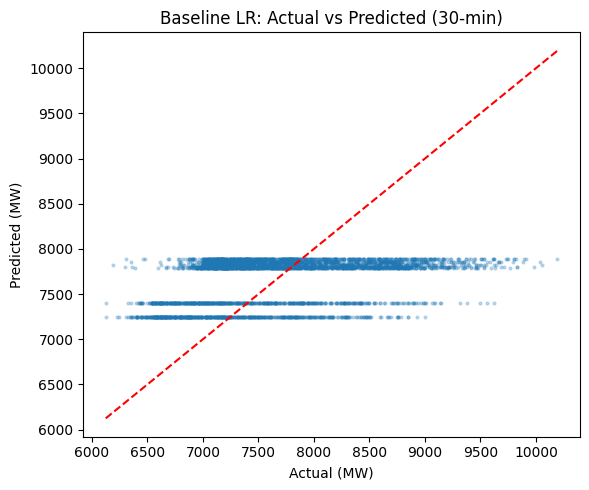

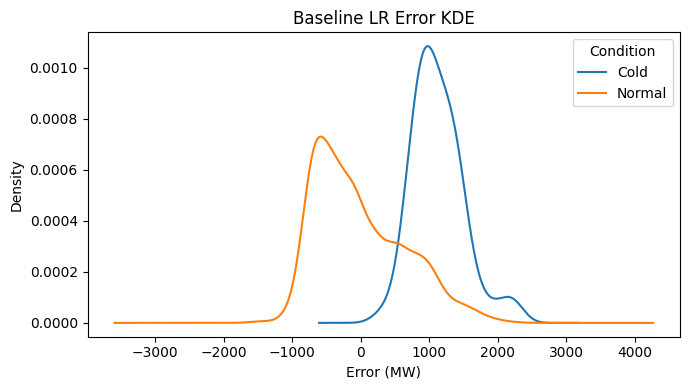

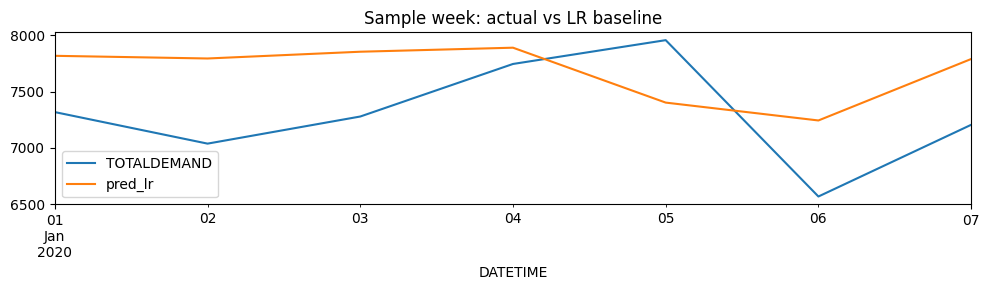

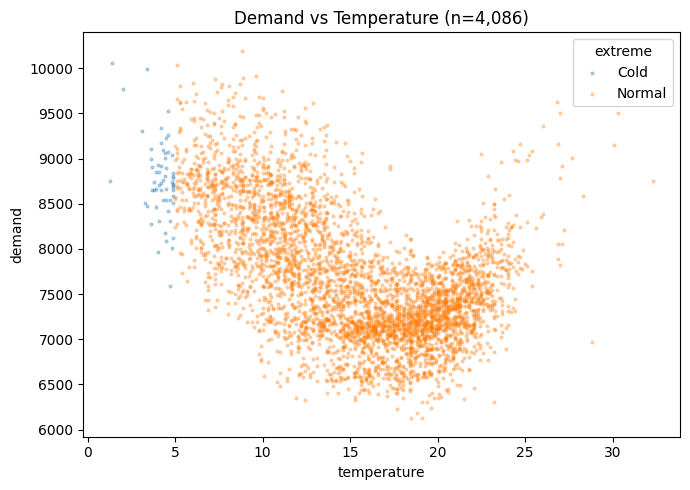

✅ Tables → /content/tables
✅ Figures → /content/figures


In [13]:
# Actual vs Pred (LR)
plt.figure(figsize=(6,5))
plt.scatter(use["TOTALDEMAND"], use["pred_lr"], s=4, alpha=0.25)
mn, mx = use["TOTALDEMAND"].min(), use["TOTALDEMAND"].max()
plt.plot([mn,mx],[mn,mx],"r--")
plt.xlabel("Actual (MW)"); plt.ylabel("Predicted (MW)")
plt.title("Baseline LR: Actual vs Predicted (30-min)")
plt.tight_layout(); plt.savefig(OUT_FIG/"baseline_lr_actual_vs_pred.png", dpi=150); plt.show()

# Error KDE by condition (LR)
plt.figure(figsize=(7,4))
for k,g in use.groupby("extreme_type"):
    (g["TOTALDEMAND"]-g["pred_lr"]).plot(kind="kde", label=k)
plt.legend(title="Condition"); plt.xlabel("Error (MW)")
plt.title("Baseline LR Error KDE")
plt.tight_layout(); plt.savefig(OUT_FIG/"baseline_lr_error_kde.png", dpi=150); plt.show()

# Sample week slice
mask = (use["DATETIME"] >= "2020-01-01") & (use["DATETIME"] < "2020-01-08")
samp = use.loc[mask, ["DATETIME","TOTALDEMAND","pred_lr"]].set_index("DATETIME")
samp.plot(figsize=(10,3))
plt.title("Sample week: actual vs LR baseline")
plt.tight_layout(); plt.savefig(OUT_FIG/"sample_week_lr.png", dpi=150); plt.show()

# Demand vs Temperature coloured by extreme
plt.figure(figsize=(7,5))
for k,g in use.groupby("extreme_type"):
    plt.scatter(g["TEMPERATURE"], g["TOTALDEMAND"], s=4, alpha=0.3, label=k)
plt.legend(title="extreme")
plt.xlabel("temperature"); plt.ylabel("demand")
plt.title(f"Demand vs Temperature (n={len(use):,})")
plt.tight_layout(); plt.savefig(OUT_FIG/"demand_vs_temperature.png", dpi=150); plt.show()

print("✅ Tables →", OUT_TAB)
print("✅ Figures →", OUT_FIG)
